In [12]:
import pandas as pd
import xarray as xr
import numpy as np
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader    
from datetime import datetime,timedelta, timezone

In [44]:
def calc_iceberg_size(iceberg_in1):
    '''Correct iceberg size not supplied with empirical relations before seeding iceberg.
    '''
    lengths = np.array(iceberg_in1['length'])
    if 'length' in iceberg_in1 and 'width' not in iceberg_in1:
        iceberg_in1['width'] = 0.7*lengths*np.exp(-0.00062*length)
    if 'length' in iceberg_in1 and np.logical_or('draft' not in iceberg_in1,'sail' not in iceberg_in1):
        rho_i, rho_w = 900,1027 #kg/m3
        height = np.array(0.4*lengths*np.exp(-0.00062*lengths))
        if np.logical_and('draft' not in iceberg_in1, 'sail' in iceberg_in1): print('Implement')
        elif np.logical_and('draft' not in iceberg_in1, 'sail' not in iceberg_in1): draft = height*(rho_i/rho_w)
        if np.logical_and('sail' not in iceberg_in1, 'draft' not in iceberg_in1): sail = height*(1-rho_i/rho_w) 
        elif np.logical_and('sail' not in iceberg_in1, 'draft' in iceberg_in1): print('Implement')
        iceberg_in1['draft'] = draft
        iceberg_in1['sail'] = sail
    return iceberg_in1

In [78]:
#Read and subset Tracker data
df = pd.read_csv('../input/Osker-X2.csv', sep=';')
df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
ds = xr.Dataset.from_dataframe(df)
ds_daily = ds.groupby("time.date").first()
ds_3day = ds_daily.isel(date=slice(0, None, 3))
idx = np.arange(ds_3day.lat.size) 
print(idx)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [99]:
env={'topaz4': 'cmems_mod_arc_phy_my_topaz4_P1D-m',
            'topaz5': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',
            'topaz5_ensemble': '',
            'topaz6': '',
            'glophyanfc': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m', #Global anfc (mercator)
            'glorys': 'cmems_mod_glo_phy_my_0.083deg_P1D-m',
            'wind_glophyre':'cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H', 
            'wind_glophynrt':'cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H',
            'era5':'../input/era5_juliette.nc'}

In [113]:
for input_l in [[env['glophyanfc'],env['wind_glophyre']],]: 
    n=5
    randspace=np.random.rand(n)
    dimensions = {'length':150+randspace*100,'width':80+randspace*10,'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1}#Initial conditions varied similarely for every position
    dimensions = calc_iceberg_size(dimensions)
    dimensions
    #dimensions = {'length':[150,200,250],'width':[80,85,90],'water_form_drag_coef':[0.25,0.6,0.9,1.5],'wind_form_drag_coef':[0.5,0.7,1.3,1.5]}#Initial conditions varied similarely for every position
    #simulation
    o=OpenBerg(loglevel=20,logfile='../results/out.log')
    o.set_config('drift:max_age_seconds', 3600*24*3)
    o.add_readers_from_list(input_l) 
    for lon, lat, time in zip(ds_3day.lon[idx],ds_3day.lat[idx],[t.values.astype(datetime) for t in ds_3day.time[idx]]):
        o.seed_elements(lon=lon, lat=lat, time=time, number=n, radius=0, **dimensions)
    oi = o.run(duration=timedelta(days=int(idx.size*3)),outfile='../results/juliette_%s.nc'%input_l)
    oi

Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00,  3.73it/s]
INFO - 2026-05-08T13:49:30Z - Selected dataset version: "202406"
INFO - 2026-05-08T13:49:30Z - Selected dataset part: "default"
Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 32.72it/s]
INFO - 2026-05-08T13:49:31Z - Selected dataset version: "202211"
INFO - 2026-05-08T13:49:31Z - Selected dataset part: "default"


(<GeoAxes: title={'center': 'OpenDrift - OpenBerg\n2025-09-24 00:00 to 2025-12-05 00:00 UTC (1729 steps)'}>,
 <Figure size 849.262x1100 with 1 Axes>)

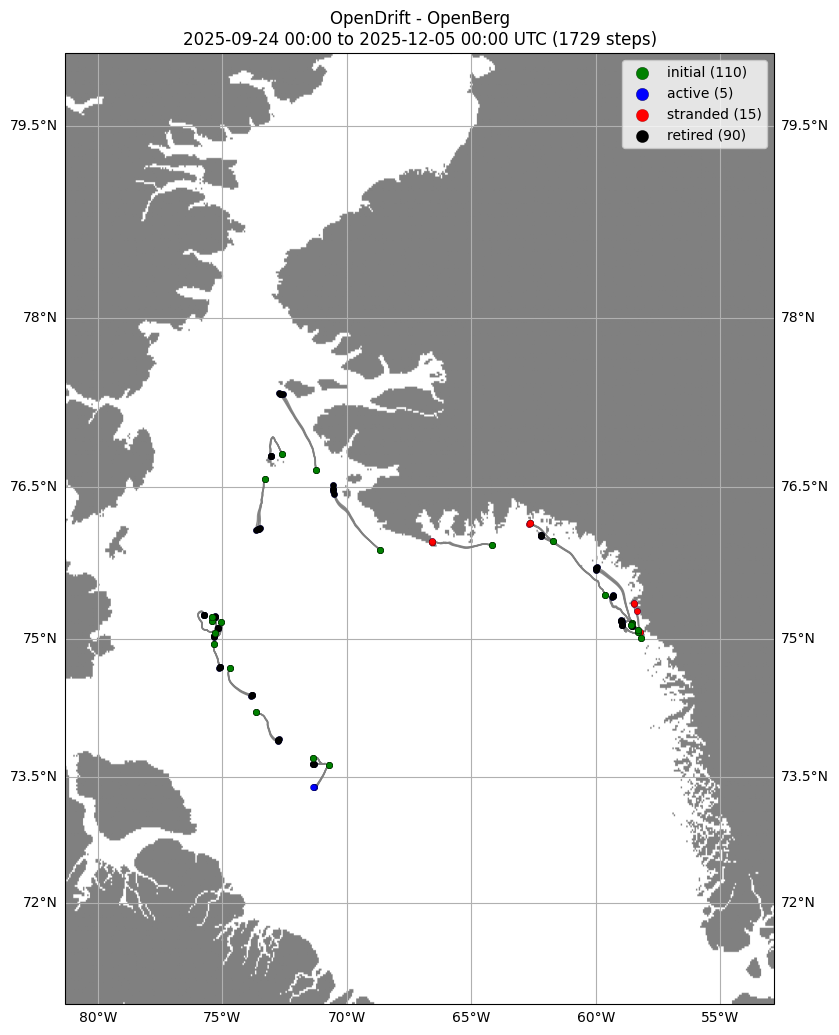

In [114]:
o.plot(fast=True,filename='../results/juliette_map_%s.png'%input_l)

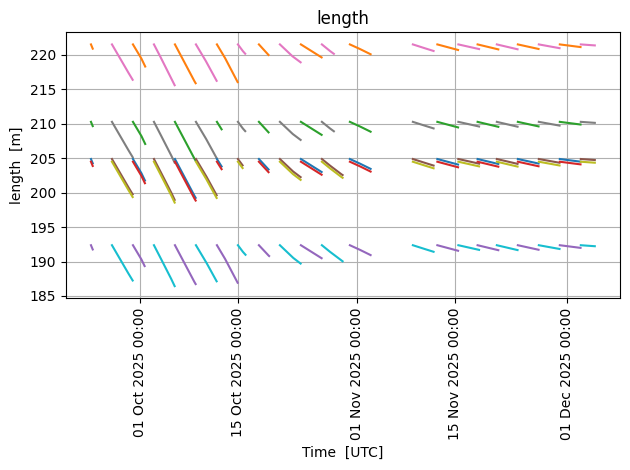

In [94]:
#o.plot_property('length')#,filename='../results/juliette_topaz4.png')